# T11a — RNN (Vanilla Recurrent Neural Network)

Uses `deep_learning.py` for all shared setup, training and evaluation.

**Model:** Vanilla RNN → known to suffer from vanishing gradients on long sequences.

In [2]:
import sys, os
from pathlib import Path

ROOT = Path(os.getcwd()).resolve().parents[1]
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
print(f"Project root: {ROOT}")

Project root: /Users/dhruvparmar/DAU/sem_2/IT_402_Applied_Forecasting_Methods/Project/Aircraft Engine Failure Forecasting


In [3]:
from src.models.deep_learning import *
import torch.nn as nn

print(f"Device: {DEVICE}")


Device: mps


## 1. Load data & build windows

In [4]:
train_df, test_df = load_data()
FEAT_COLS  = select_features(train_df)
N_FEATURES = len(FEAT_COLS)

# Engine-level train/val split (no leakage)
X_train, y_train, X_val, y_val = engine_split(train_df, FEAT_COLS)

# Test windows (last window per engine)
X_test, y_test = build_windows(test_df, FEAT_COLS, is_test=True)

train_loader, val_loader, test_loader = make_loaders(
    X_train, y_train, X_val, y_val, X_test, y_test
)


Train shape : (61249, 105)  (249 engines)
Test  shape : (41214, 105)   (248 engines)
Feature columns (42): ['s2_rmean_5', 's3_rmean_5', 's4_rmean_5', 's7_rmean_5', 's8_rmean_5'] ...
Train engines: 199  Val engines: 50
X_train: (42725, 30, 42)  X_val: (50, 30, 42)
Train batches: 334  Val batches: 1


## 2. Model definition

Vanilla RNN — simplest recurrent architecture. Susceptible to vanishing gradients for long sequences.

In [11]:
class MLP(nn.Module):
    """
    MLP — no recurrence, treats window as flat feature vector.
    WHY include: strongest non-temporal baseline.
    If MLP ≈ LSTM, the temporal structure isn't helping.
    """
    def __init__(self, n_features, window_size=WINDOW_SIZE,
                 hidden_size=128, dropout=0.2):
        super().__init__()
        input_dim  = n_features * window_size  
        self.net   = nn.Sequential(
            nn.Linear(input_dim,   hidden_size),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size, 1),   # 3 outputs
        )

    def forward(self, x):
        # x: (B, W, F) → flatten → (B, W*F)
        x = x.view(x.size(0), -1)
        return self.net(x).squeeze(-1)

model = MLP(N_FEATURES)
n_params = sum(p.numel() for p in model.parameters())
print(f"MLP parameters: {n_params:,}")

MLP parameters: 178,049


## 3. Train

In [13]:
model, train_losses, val_losses = train_model(
    model        = model,
    train_loader = train_loader,
    val_loader   = val_loader,
    epochs       = EPOCHS,
    model_name   = "MLP",
)


  [MLP] Epoch  10 | train=240.4107 | val=117.8565 | best=107.5228
  [MLP] Epoch  20 | train=198.2036 | val=64.7962 | best=64.7962
  [MLP] Epoch  30 | train=174.4517 | val=75.0137 | best=64.7962
  [MLP] Early stop at epoch 30


## 4. Evaluate

In [15]:
from src.evaluation.metrics import evaluate

y_true, y_pred = predict_test(model, test_loader)
y_pred = y_pred.ravel()
results = evaluate(y_true, y_pred, model_name="MLP")
print(results)


  [MLP] RMSE: 13.9782  |  NASA Score: 1031.94 (mean: 4.16)  |  R2: 0.8942  |  Bias: +1.44 (late ↑)
{'rmse': 13.978249549865723, 'nasa_score': 1031.9354248046875, 'nasa_score_mean': 4.1610299387285785, 'r2_score': 0.8942331671714783, 'bias': 1.4449034929275513}


## 5. Plots

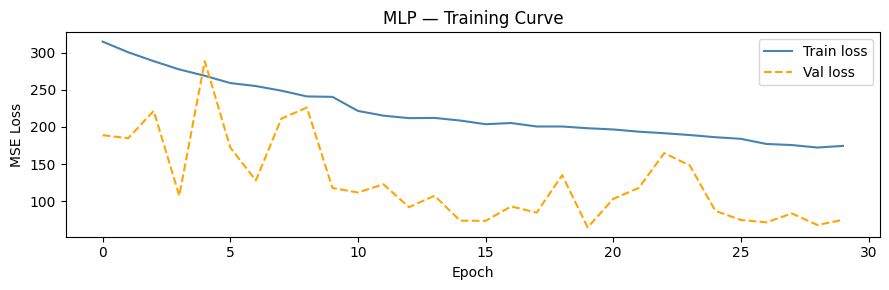

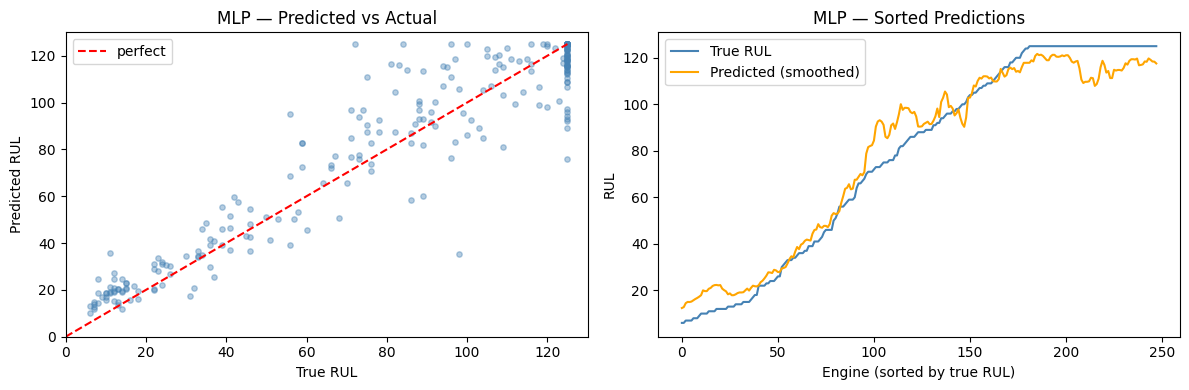

In [16]:
plot_loss_curves(train_losses, val_losses, model_name="MLP")
plot_predictions(y_true, y_pred, model_name="MLP")
